In [1]:
# Check the maps and get the data from the pixel locations
# which should match up to those used in 
# Hannah & Kontar 2013 https://doi.org/10.1051/0004-6361/201117576
# 
# 20 Mar 2026 IGH

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sunpy.io.special import read_genx
import sunpy.map
from astropy.coordinates import SkyCoord
from astropy import units as u

import warnings
warnings.simplefilter('ignore')
plt.rcParams.update({'font.size': 18,'font.family':"sans-serif",\
                         'font.sans-serif':"Ubuntu",'mathtext.default':"regular"})

In [3]:
# Original save genx structure (array of maps) doesn't work in python?
# d=read_genx('DCPsmap16_20101103_121502.genx')


In [4]:
d094=sunpy.map.Map('map_094.fits')
d131=sunpy.map.Map('map_131.fits')
d171=sunpy.map.Map('map_171.fits')
d193=sunpy.map.Map('map_193.fits')
d211=sunpy.map.Map('map_211.fits')
d335=sunpy.map.Map('map_335.fits')

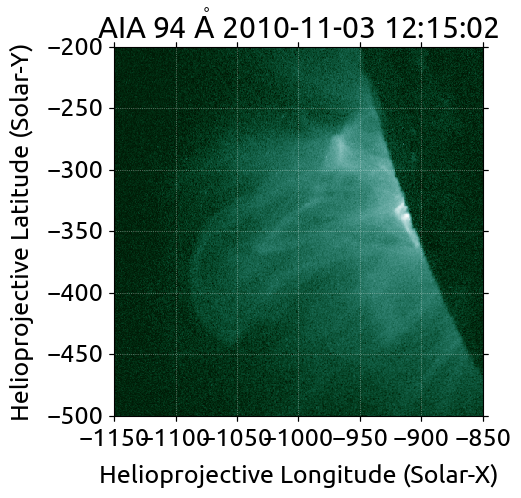

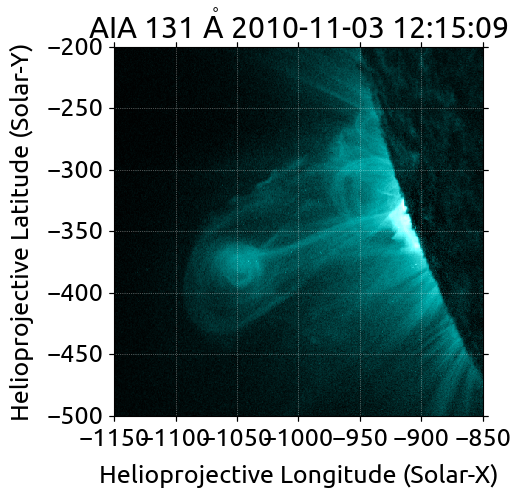

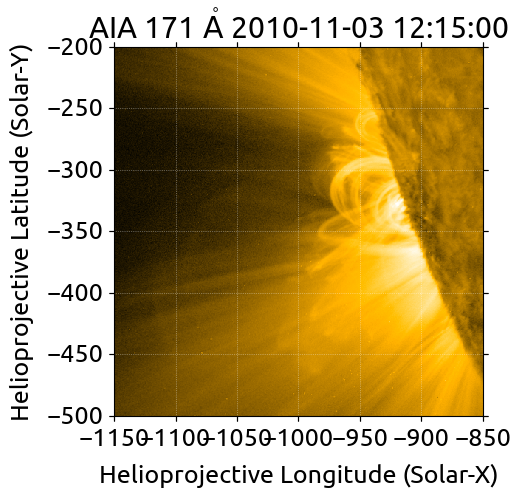

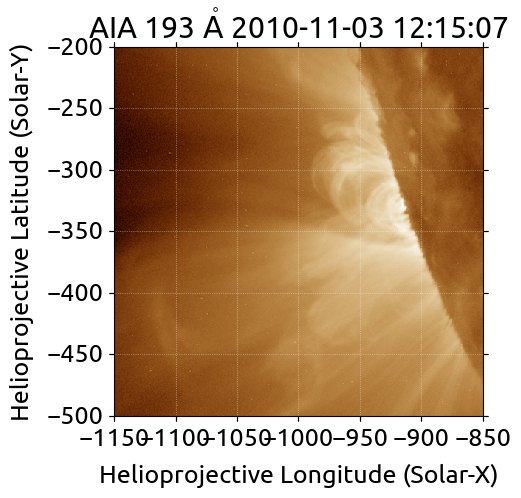

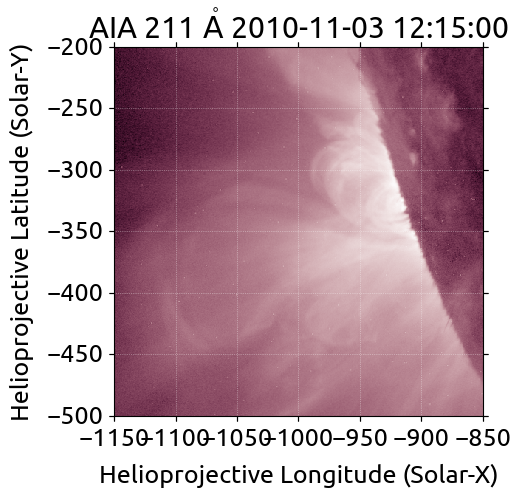

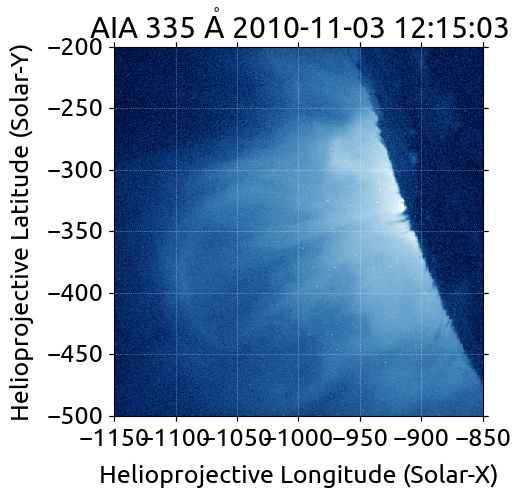

In [5]:
d094.plot()
plt.show()

d131.plot()
plt.show()

d171.plot()
plt.show()

d193.plot()
plt.show()

d211.plot()
plt.show()

d335.plot()
plt.show()

In [6]:
positions = {
    '1': {'x': 171, 'y': 200},
    '2': {'x': 265, 'y': 240},
    '3': {'x': 80,  'y': 400},
    '4': {'x': 180, 'y': 400},
    '5': {'x': 300, 'y': 100},
    '6': {'x': 385, 'y': 250},
    '7': {'x': 110, 'y': 140},
    '8': {'x': 101, 'y': 130},
}

positions

{'1': {'x': 171, 'y': 200},
 '2': {'x': 265, 'y': 240},
 '3': {'x': 80, 'y': 400},
 '4': {'x': 180, 'y': 400},
 '5': {'x': 300, 'y': 100},
 '6': {'x': 385, 'y': 250},
 '7': {'x': 110, 'y': 140},
 '8': {'x': 101, 'y': 130}}

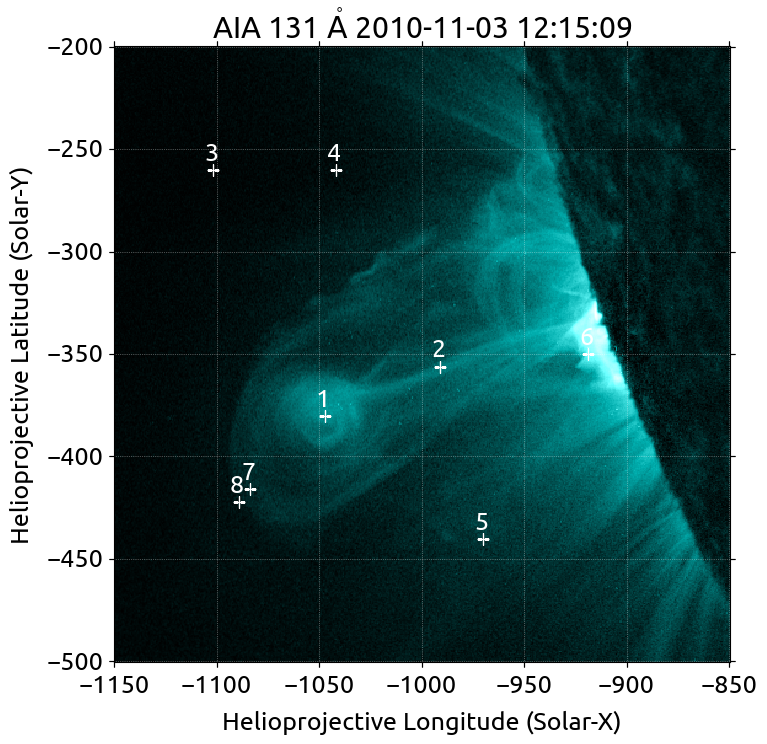

In [7]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=d131)
d131.plot(axes=ax)

for name, p in positions.items():
    xpix = p["x"] * u.pix
    ypix = p["y"] * u.pix
    ax.plot(xpix,ypix,'+',color='w',markersize=8)
    ax.text(p["x"]-7,p["y"]+8,name,color='w')
plt.show()

In [8]:
dns=np.zeros([6,8])

for i, (name, p) in enumerate(positions.items()):
    print(name,p['x'],p['y'])
    dtemp=d094.data.T/d094.exposure_time.value
    dns[0,i]=dtemp[p['x'],p['y']]
    dtemp=d131.data.T/d131.exposure_time.value
    dns[1,i]=dtemp[p['x'],p['y']]
    dtemp=d171.data.T/d171.exposure_time.value
    dns[2,i]=dtemp[p['x'],p['y']]
    dtemp=d193.data.T/d193.exposure_time.value
    dns[3,i]=dtemp[p['x'],p['y']]
    dtemp=d211.data.T/d211.exposure_time.value
    dns[4,i]=dtemp[p['x'],p['y']]
    dtemp=d335.data.T/d335.exposure_time.value
    dns[5,i]=dtemp[p['x'],p['y']]
    print(np.array2string(dns[:,i], formatter={"float_kind": lambda x: f"{x:.4f}"}))

1 171 200
[8.5871 70.7579 95.7223 383.0090 172.2257 17.5911]
2 265 240
[9.8286 41.7721 292.6255 1156.8846 493.8714 43.5764]
3 80 400
[0.6664 1.2163 35.7115 103.2071 41.7922 3.2692]
4 180 400
[3.0924 1.6842 63.1232 189.4902 86.8029 8.3043]
5 300 100
[6.5778 15.2298 505.5560 882.3551 299.3623 18.9884]
6 385 250
[33.6575 370.3191 1660.7642 4025.5738 1525.3113 189.4008]
7 110 140
[2.0251 10.6974 102.8958 311.3233 131.9623 11.5801]
8 101 130
[1.6036 2.2047 95.0057 273.7639 125.0131 9.1095]


In [9]:
print(np.array2string(dns, formatter={"float_kind": lambda x: f"{x:.3f}"}))

[[8.587 9.829 0.666 3.092 6.578 33.658 2.025 1.604]
 [70.758 41.772 1.216 1.684 15.230 370.319 10.697 2.205]
 [95.722 292.626 35.712 63.123 505.556 1660.764 102.896 95.006]
 [383.009 1156.885 103.207 189.490 882.355 4025.574 311.323 273.764]
 [172.226 493.871 41.792 86.803 299.362 1525.311 131.962 125.013]
 [17.591 43.576 3.269 8.304 18.988 189.401 11.580 9.110]]
